![logo](./figures/LogoLine_horizon_C3S.png)

# Tutorial on regional precipitation projections and their uncertainty
In this tutorial, we reproduce some of the results and figures presented in the regional component of the C3S Atlas (https://atlas.climate.copernicus.eu/). In particular, we focus on computing long-term precipitation projection changes for two regions, together with an assessment of their associated uncertainty.

In climate change studies, a key objective is to evaluate how climate variables are projected to evolve in the future under external forcing (e.g. different greenhouse gas emission scenarios). The changes in the variables are typically defined as the difference between certain periods of future projections and historical simulations. Depending on the selected future time period, changes can be classified as near-term, mid-term, or long-term. In this tutorial, we focus on long-term changes under the SSP5-8.5 scenario.

To ensure a robust assessment of the climate change signal, a multi-model ensemble must be considered. Each model represents the climate system differently, due to variations in representation of physical process, parameterizations, and resolution, resulting in differences in their projections. Using a multi-model ensemble allows us to quantify the spread of results and to assess the confidence in the projected changes in a statistical framework. Here, the data of the climate model ensemble will be retrieved from the [C3S Atlas Dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview).

In [C3S Atlas](https://atlas.climate.copernicus.eu/atlas), and hence in this notebook, the uncertainty is evaluated following the methodology described in Cross-Chapter Box Atlas 1: “Displaying Robustness and Uncertainty in Maps” from the IPCC AR6 WGI Atlas (https://doi.org/10.1017/9781009157896.021; pp. 1945–1950), which is based on (1) multi-model agreement on the sign of the change (positive or negative), and (2) comparing the magnitude of the change with the internal variability estimated from the historical period (internal variability threshold). These concepts will be explained in detail later.

The workflow of the notebook is as follows. First, the required climate projections from the [CMIP6](https://wcrp-cmip.org/cmip-phases/cmip6/) project is downloaded from the [C3S Atlas Dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) and the climate change signal is computed. Then, two regions (Mediterranean and Western-Africa) with robust and non-robust climate change signals are selected and compared. The comparison includes the uncertainty assessment, by analyzing both the inter-model spread and the multi-model mean.

# 1. Data download and preparation
Before starting, we need to prepare the environment. This includes two steps: 1) Installing the CDS API, 2) Importing the specific python libraries to be used.

## 1.1 Install CDS API
To download the required data we will use CDS API (Application Programming Interface). This allows users to automate downloads and data retrievals using Python scripts instead of manually browsing at the CDS website (https://cds.climate.copernicus.eu/). It lets you select specific data, variables, and time ranges to download efficiently huge volumes of climate information for research or analysis. To install the CDS API, run the following command.

In [ ]:
!pip install cdsapi

## 1.2 Import libraries
Python libraries are collections of pre-written code (functions, modules, classes) that provide ready-to-use solutions for specific tasks without the need for writing everything from scratch.

In climate science, we are generally working with data in `NetCDF` format. To best handle this data we will use libraries for working with labelled multi-dimensional arrays, in particular `Xarray`. In addition, it is also practical to use `NumPy`, which supports large multi-dimensional arrays, along with a large collection of high-level mathematical functions to operate on these arrays. For plotting and viewing data, we will use `Matplotlib` and `Cartopy`. Warnings related to data downloads via the `CDS API` (e.g., server security, connection issues, download size, or data availability) are disabled using `urllib3`. Finally, the `glob` and `zipfile` modules are imported to search for and extract files, respectively.

In [5]:
# CDS API
import cdsapi

# Libraries for working with multi-dimensional arrays
import numpy as np
import xarray as xr

# Libraries for plotting and visualising data
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

# Disable warnings for data download via API
import urllib3 
urllib3.disable_warnings()

# Search for files and directories using patterns
from glob import glob

# Extract zipfile
import zipfile 

## 1.3 Enter your CDS API key
We will request data from the CDS programmatically with the help of the `CDS API`. To set up the `CDS API` credentials, we need to define two variables: `URL` and `KEY`. These can be obtained by registering and login to the CDS (https://cds.climate.copernicus.eu), and following the instructions in https://cds.climate.copernicus.eu/how-to-api.

In [97]:
URL = 'https://cds.climate.copernicus.eu/api'
KEY = ''

Next, we specify a data directory in which we will download our data and all output files that we will generate:

In [6]:
DATADIR = './'

## 1.4 Download C3S Atlas data
To search for the C3S Atlas data, visit the CDS website: https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=download. The C3S Atlas collects several databases including observations, reanalysis and climate change projections both at global and regional scales. In this notebook, we will focus on the CMIP6 global climate projection database, which corresponds to the 6th phase of the Coupled-Model Intercomparison Project. 

The data used to evaluate the precipitation projections is the global 'Monthly Precipitation' covering the period from 1850 to 2100. Although this full time span is not provided by a single CMIP6 experiment, it can be obtained by combining two experiments: historical and scenario (SSP5-8.5 in our case). The historical experiment simulates climate conditions from 1850 to 2014 and represents the recent past climate. To explore potential future climate changes, several long-term projection experiments simulate the evolution of the climate system from 2015 to 2100 under different (radiative forcing and socio-economic) assumptions. Among the available scenarios, we focus on SSP5-8.5, a high-emissions pathway that results in a pronounced anthropogenic climate change signal that clearly emerges from natural variability. To obtain the projected changes, consistency between datasets must be ensured, so the same models must be included in both the historical and scenario samples. This requirement will be highlighted later.

After selecting the desired data request, click "Show API request" at the bottom of the download form. This will reveal a block of code, which you can simply copy and paste into a cell of your Jupyter Notebook. Running the cell will retrieve and download the data you requested into your local directory. The download may take a few minutes depending on the volume of the data. Note that, the terms and conditions of this particular dataset need to be accepted in the CDS. The option to view and accept these conditions is given just above the “Show API request” option.

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Project:** `C3S Atlas dataset`\
**Origin:** `CMIP6`\
**Variables:** `Monthly Precipitation`  
**Experiment:** `historical; SSP5-8.5`  
**Year:** `1850-2014; 2015-2100`  

In [ ]:
# Download data for Historical Runs
c = cdsapi.Client(url=URL, key=KEY)
c.retrieve("multi-origin-c3s-atlas",
    {
    "origin": "cmip6",
    "experiment": "historical",
    "domain": "global",
    "period": "1850-2014",
    "variable": "monthly_precipitation",
    "bias_adjustment": "no_bias_adjustment"
},
     f'{DATADIR}cmip6_monthly_1850-2014_historical.zip')

In [ ]:
# Download data for Future Scenario Runs
c = cdsapi.Client(url=URL, key=KEY)
c.retrieve("multi-origin-c3s-atlas",
    {
    "origin": "cmip6",
    "experiment": "ssp5_8_5",
    "domain": "global",
    "period": "2015-2100",
    "variable": "monthly_precipitation",
    "bias_adjustment": "no_bias_adjustment"
},
    f'{DATADIR}cmip6_monthly_2015-2100_ssp585.zip')

# 2. Data processing
### Unzip the downloaded data files
From the CDS, CMIP6 data are available as `NetCDF` files compressed into zip archives. Therefore, before loading any data, we have to extract the files. After downloading the two experiments (historical and SSP5-8.5) as separate zip files, we can use the functions from the zipfile Python package to extract their contents. For each zip file, a `ZipFile()` object is generated and then, the content is extracted with the function `extractall()`.


In [5]:
# Extract .zip files inside the folder
cmip6_zip_paths = glob(f'{DATADIR}*.zip')
for j in cmip6_zip_paths:
    with zipfile.ZipFile(j, 'r') as zip_ref:
        zip_ref.extractall(f'{DATADIR}')

# 3. Open data and compute climate change signals
### Load and prepare CMIP6 data for all experiments


Now that we have downloaded and extracted the data, we can prepare it. These preparation steps include:

- **Temporal aggregation**: The data are aggregated from monthly to annual values because the uncertainty analysis is performed at this temporal resolution. Note that if a specific season or month is to be analyzed, the corresponding temporal filter must be applied prior to calculating both the uncertainty analysis and the climate change signal.
- **Reference period selection**: The climatologies are defined for 1971–2005 for the historical period and 2081–2100 for the long-term SSP5-8.5 scenario. Typically, the longest reference period is used to assess natural variability and evaluate the robustness of the climate signal; however, to ensure consistency between the CMIP6 and CORDEX projections used in the C3S Atlas, we adopt their longest common historical overlap period, 1971–2005, as the reference period for both datasets.

As we are working with large volumes of data, we define 'chunks' in `xr.open_dataset()` to divide the dataset into smaller blocks. This enables more efficient processing without loading the entire dataset into memory. The compute() function is then used to trigger the actual computation and avoid slow execution.

In [ ]:
# Load data, group by 'year' and period selection

# Historical
ds = xr.open_dataset(f'{DATADIR}r_CMIP6_historical_mon_185001-201412_v02.nc', chunks={"time": 120})
ds_hist = ds['r'].sel(time=slice("1971", "2005")) .groupby('time.year').mean().compute()
ds_hist_std = ds_hist # will be used later for computing the standard deviation
ds_hist = ds_hist.sel(year=slice("1986", "2005")) 

# SSP5-8.5
ds = xr.open_dataset(f'{DATADIR}r_CMIP6_ssp585_mon_201501-210012_v02.nc', chunks={"time": 120})
ds_ssp = ds['r'].sel(time=slice("2081", "2100")).groupby('time.year').mean().compute() 

The data includes (`member`, `year`, `lat`, `lon`) dimensions. The `member` coordinate is a numerical index that indicates the number of models for the historical and SSP5-8.5 experiments. However, the dataset provides several alternative options to describe the ensemble members, depending on the intended analysis. These include:

- `member_id`: contains the full information about each model run.
- `gcm_institution`: indicates the originating institution.
- `gcm_model`: provides the model names.
- `gcm_variant`: describes the specific experiment configuration.

Since our goal is to compare the same models with the same configurations in both historical and scenario simulations, we focus on identifying the same members using the `member_id` variable.

### Select sample
As mentioned earlier, consistency across samples must be ensured, but sometimes different experiments are not available to the same samples of models. In this case, the historical experiments contain 30 models, while the SSP5-8.5 scenario has only 27. Since we are interested in long-term climate evolutions from 1850 to 2100, we keep only those models present in both historical and SSP5-8.5 experiments.

In [9]:
# Identify and select common models in both experiments
common = np.intersect1d(ds_hist.member_id, ds_ssp.member_id) # identify

ds_hist = ds_hist.where(ds_hist.member_id.isin(common), drop=True)
ds_hist_std = ds_hist_std.where(ds_hist_std.member_id.isin(common), drop=True)
ds_ssp  = ds_ssp.where(ds_ssp.member_id.isin(common), drop=True)

### Compute climate change signals
Once the data is prepared, we compute the future climate change signals. The latter are obtained as the difference between the climatological means of the future and the past periods corresponding to the SSP5-8.5 and historical simulations, respectively. The results are expressed using two metrics: (1) relative change with respect to the historical period [%], and (2) absolute change [mm day⁻¹].


In [10]:
# Projections
# (1) Relative change
proj_prct = (ds_ssp.mean(dim='year') - ds_hist.mean(dim='year')) / ds_hist.mean(dim='year') .where(np.isfinite(ds_hist.mean(dim='year'))) * 100
# (2) Absolute change
proj = (ds_ssp.mean(dim='year') - ds_hist.mean(dim='year') )                                                
    
proj_prct_mean = proj_prct.mean(dim="member", skipna=True)

# 4. Import and select regions
The future projections of precipitation are aimed to be analysed at a regional scale. To do so, we will select two regions (Mediterranean and Western-Africa) from those defined in IPCC AR6 framework (https://regionmask.readthedocs.io/en/stable/defined_scientific.html#ar6-regions), and assess the associated uncertainties in the projected changes.

First, we install and import the IPCC AR6 regions from the [Regionmask](https://regionmask.readthedocs.io/en/stable/) Python module and display the corresponding region names. After selecting the regions of interest (which are the Mediterranean region and Western-Africa in our case), we apply the mask to both projection fields (relative and absolute changes) and we create a single variable containing both regions.

In [ ]:
# Import regionmasks 
!pip install regionmask
import regionmask
ar6 = regionmask.defined_regions.ar6.all
mask = ar6.mask(proj_prct_mean)

In [12]:
# Display Region Names
ar6.names

['Greenland/Iceland',
 'N.W.North-America',
 'N.E.North-America',
 'W.North-America',
 'C.North-America',
 'E.North-America',
 'N.Central-America',
 'S.Central-America',
 'Caribbean',
 'N.W.South-America',
 'N.South-America',
 'N.E.South-America',
 'South-American-Monsoon',
 'S.W.South-America',
 'S.E.South-America',
 'S.South-America',
 'N.Europe',
 'West&Central-Europe',
 'E.Europe',
 'Mediterranean',
 'Sahara',
 'Western-Africa',
 'Central-Africa',
 'N.Eastern-Africa',
 'S.Eastern-Africa',
 'W.Southern-Africa',
 'E.Southern-Africa',
 'Madagascar',
 'Russian-Arctic',
 'W.Siberia',
 'E.Siberia',
 'Russian-Far-East',
 'W.C.Asia',
 'E.C.Asia',
 'Tibetan-Plateau',
 'E.Asia',
 'Arabian-Peninsula',
 'S.Asia',
 'S.E.Asia',
 'N.Australia',
 'C.Australia',
 'E.Australia',
 'S.Australia',
 'New-Zealand',
 'E.Antarctica',
 'W.Antarctica',
 'Arctic-Ocean',
 'N.Pacific-Ocean',
 'Equatorial.Pacific-Ocean',
 'S.Pacific-Ocean',
 'N.Atlantic-Ocean',
 'Equatorial.Atlantic-Ocean',
 'S.Atlantic-Ocean',


In [13]:
# Select the regions
reg_id_1 = ar6.map_keys("Mediterranean")
reg_id_2 = ar6.map_keys("Western-Africa")

# Apply the region masks to the percentage projection field [%]
proj_prct_med = proj_prct.where(mask == reg_id_1)
proj_prct_waf = proj_prct.where(mask == reg_id_2)

proj_prct_region = xr.concat([proj_prct_med, proj_prct_waf], dim="region") # Create a single file for both regions
proj_prct_region = proj_prct_region.assign_coords(region=["Mediterranean", "Western-Africa"])

# Apply the region masks to the total projection field [mm day-1]
proj_med = proj.where(mask == reg_id_1)
proj_waf = proj.where(mask == reg_id_2)

proj_region = xr.concat([proj_med, proj_waf], dim="region") # Create a single file for both regions
proj_region = proj_region.assign_coords(region=["Mediterranean", "Western-Africa"])

# 5. Regional mean projections
Once the changes have been computed and the regions selected, we analyse the mean precipitation changes over each region. For each model, the regional mean is obtained by averaging the data over latitude and longitude, resulting in a single value per model. This allows to observe the inter-model spread in the results: how differently models project the future.

To draw conclusions about these projection changes, the uncertainty must be evaluated. This requires introducing two key concepts: model agreement and the internal variability threshold. These concepts are described in detail in Cross-Chapter Box Atlas 1 of the IPCC AR6 WGI Atlas (https://doi.org/10.1017/9781009157896.021; pp. 1945–1950).

### Uncertainty: Model agreement and comparison to natural variability
In the IPCC AR6 WGI Atlas, the uncertainty is evaluated by analysing two complementary aspects: 1) the level of agreement among models, and 2) the projected changes compared to the historical natural variability.

1) **Model agreement** refers to the degree to which different climate models project the same (or different) direction of change for a given variable. It is commonly assessed by examining how many models agree on the sign of the projected change (for example, increase or decrease). High model agreement indicates that a substantial fraction of models produce similar results, which increases confidence in the robustness of the projection, although it does not imply absolute certainty.

2) The comparison of the projected change to **internal variability** is used to assess whether the projected signal is robust and distinguishable from natural climate fluctuations, or whether it could simply reflect internal noise. Internal variability is typically estimated using the longest available historical period (from 1850 to the present), spanning the pre-industrial period to today, and represents the range of natural variations simulated by the models in the absence of future forcing. The projected change is then evaluated relative to this variability. If the projected signal is larger than a certain internal variability threshold (defined next), it is considered to clearly emerge from the noise. If it is comparable to or smaller than the internal variability, the projection is less robust, even if many models agree on the direction of change.
The variability threshold is often defined as **γ = √2 · 1.645 · σ**, where σ is the standard deviation of 20-year means estimated from non-overlapping periods in the pre-industrial simulations. In this formulation, the factor √2 arises because we are considering the variability of a difference between two independent climate periods (e.g., a future period minus a reference period). When two independent random variables with the same variance are subtracted, their variances add, so the variance of the difference becomes σ² + σ² = 2σ², and therefore the standard deviation becomes √2 · σ. Thus, √2 accounts for the combined uncertainty of both periods involved in the climate change signal. The factor 1.645 corresponds to the 90% confidence level, meaning that, for a normal distribution, there is a 90% probability that values lie within ±1.645 standard deviations of the mean.

### Compute the historical standard deviation
In cases where the length of the historical period does not allow for the calculation of the standard deviation of 20-year means from non-overlapping periods, because the record is too short (as in this case, where only 35 years are available; 1971–2005), the following approximation is applied instead: **γ = √(2/20)·1.645·σ₁yr**, where σ₁yr is the interannual historical standard deviation calculated from a linearly detrended modern period (σ₂₀yr = σ₁yr / √20). Here, the historical standard deviation is computed over the period 1971–2005 (following C3S Atlas methodology), therefore, the second approximation is used.

The above approximation allows comparison between a climate change signal defined over 20-year periods and variability estimated from annual data. In this framework, the annual standard deviation is scaled to approximate the variability of 20-year means, making the metrics comparable in terms of temporal aggregation. If long continuous simulations (e.g., from 1850 onwards) were available, the preferred approach would be to directly compute the standard deviation of non-overlapping 20-year means, which is fully consistent with the temporal scale of the climate change signal being assessed.

In [14]:
from scipy.signal import detrend

hist_std_detrended = xr.apply_ufunc(
    detrend,
    ds_hist_std,
    input_core_dims=[["year"]],
    output_core_dims=[["year"]],
    vectorize=True,
    dask="parallelized",
    kwargs={"axis": -1}
)

In [15]:
# Standard Deviation
hist_std_smooth = hist_std_detrended.std('year')

# Apply mask to historical Standard Deviation field
hist_std_smooth_med = hist_std_smooth.where(mask == reg_id_1)
hist_std_smooth_waf = hist_std_smooth.where(mask == reg_id_2)

hist_std_smooth_region = xr.concat([hist_std_smooth_med, hist_std_smooth_waf], dim="region")
hist_std_smooth_region = hist_std_smooth_region.assign_coords(region=["Mediterranean", "Western-Africa"])

### Plotting the projected regional mean
The following figure illustrates the CMIP6 precipitation changes inter-model spread for the Mediterranean and Western-Africa regions, that is, the extent to which different models simulate future precipitation over these areas. The bars in the figure represent the regionally averaged precipitation changes for each model, so that each bar corresponds to an individual model.

In addition, the regional internal variability threshold is displayed as a red dot alongside the projected precipitation changes. This allows the climate change signal to be compared with natural variability, and helps to assess whether the projected changes are large enough to clearly emerge from it.

Several conclusions can be drawn from the figure:

- The Mediterranean region exhibits a robust decrease in precipitation due to climate change. This is supported by the strong model agreement on a decrease in mean precipitation (all models agree on a negative sign of change), as well as by the fact that, in most models, the magnitude of the change exceeds the internal variability threshold (all but three models). Thus, the projected changes present low uncertainty
- In contrast, no robust or consistent signal emerges for the Western-Africa region. Although most models simulate changes that exceed the internal variability threshold (i.e., the bars are larger than the corresponding dots), the direction of change remains uncertain. Consequently, precipitation projections for this region are associated with a high degree of uncertainty. Nevertheless, the likelihood of an increase appears to be somewhat higher, as approximately three-quarters of the models project an increase in precipitation, while the remaining models indicate a decrease.

Note that, in this figure, the results are aggregated over relatively large areas, which reduces the internal variability of the projections in the historical period. When this analysis is performed at the grid-cell level, the climate change signal is more difficult to distinguish from natural variability.

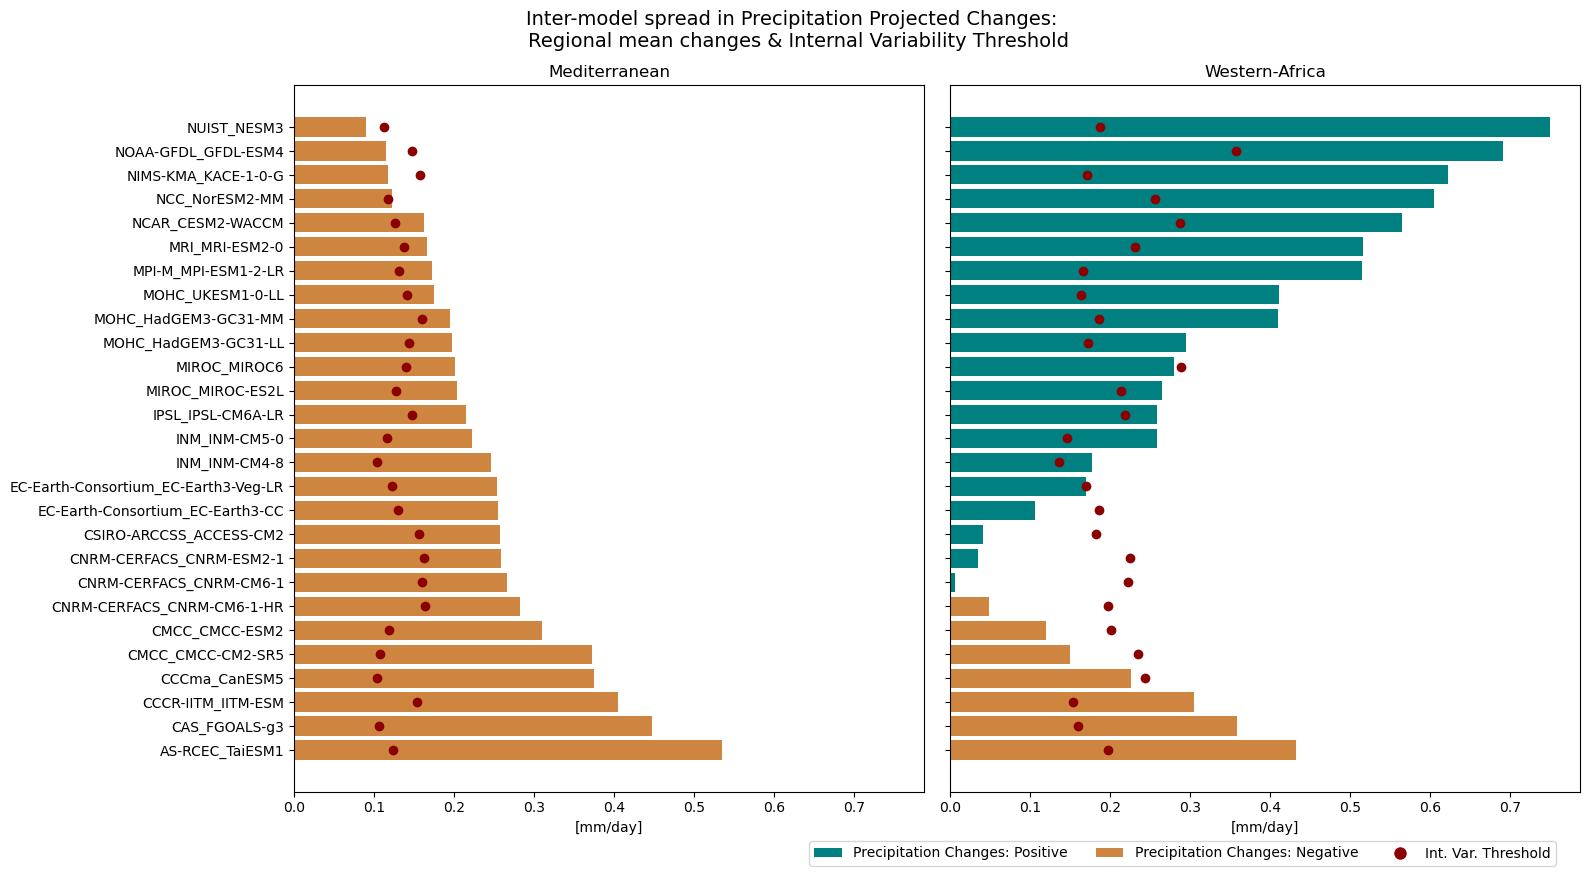

In [105]:
# Figure: Comparison between Precipitation Projections and Natural Variability
fig, ax = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)
for i in range(2):

    da = proj_region.mean(dim=['lat','lon'], skipna=True).isel(region=i)
    # Compute variability threshold
    gamma = ((2/20)**0.5)*1.645*hist_std_smooth_region.mean(dim=['lat','lon'], skipna=True).isel(region=i) # gamma
    
    
    # Sort regional values
    da_sorted = da.sortby(da)
    positive = da_sorted > 0
    
    # Plot
    ax[i].barh(
        da_sorted.member.values,
        abs(da_sorted.values), 
        color = np.where(positive, "teal", "peru")
    )
    ax[i].scatter(
        gamma.values,
        da_sorted.member.values,
        zorder = 3,
        color = "darkred"
    )
    
    ax[i].set_xlabel("[mm/day]")
    ax[i].set_title(f"{da.region.values}")

ax[0].set_yticks(np.arange(len(proj_region.member.values)))
ax[0].set_yticklabels(['_'.join(mem.split('_')[0:-1]) for mem in proj_region.member_id.values])
    
legend_elements = [
    Patch(facecolor="teal", label="Precipitation Changes: Positive"),
    Patch(facecolor="peru", label="Precipitation Changes: Negative"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='darkred', markersize=10,
           label="Int. Var. Threshold")
]

fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(0.98, 0.02), ncol=3)

plt.tight_layout()
fig.suptitle("Inter-model spread in Precipitation Projected Changes: \n Regional mean changes & Internal Variability Threshold", y=1.05, fontsize=14)
plt.show()


# 6. Projected spatial patterns
Now, we move to reproduce the regional spatial patterns of future precipitation changes together with their associated uncertainty. The spatial patterns are obtained by computing the ensemble mean of precipitation changes across all models, resulting in a two-dimensional field defined by latitude and longitude.

It is important to note that the ensemble mean is included here only as background information to facilitate the interpretation of the uncertainty analysis. By itself, the ensemble mean does not provide sufficient information to assess the reliability of the projected changes, as it masks the spread and agreement among the individual model simulations. Therefore, the ensemble mean should not be interpreted as a substitute for a proper ensemble evaluation. Instead, it should always be considered jointly with the corresponding uncertainty metrics, which provide the necessary context for understanding the confidence and consistency of the projected spatial patterns.
 
### Representation of the Uncertainty in maps
As mentioned above, the uncertainty in climate projections is assessed using two complementary metrics: the level of agreement among models regarding the direction of change (model agreement), and the extent to which the projected signal emerges from natural variability (internal variability threshold). In the previous figure, the uncertainty assessment was performed in a simplified way (just observing the values of both metrics).

However, the uncertainty in spatial maps is usually represented using more **advanced approaches** that combines these two metrics in different ways. In this section, we adopt the methodology used in the AR6 framework, which classifies uncertainty into three categories (see the details in IPCC AR6 Cross-Chapter Box Atlas.1; https://doi.org/10.1017/9781009157896.021; pp. 1945–1950): 

a) **Robust change**: areas where there is model agreement in the direction of change (consistency across models > 80%), and the climate change signal emerges from internal variability (it exceeds the variability threshold in ≥66% of the models). As mentioned above, the variability threshold is defined as γ = √2·1.645·σ, where σ is the standard deviation of 20-year means, here computed from the historical simulation. Represented by 'colour' (no overlay).

b) **Conflicting changes/signals**: areas where the signal emerges from internal variability but there is no agreement in the projection sign. Represented by 'crossed lines'.

c) **No change or no robust change**: areas where <66% of models show change greater than variability threshold. Represented by 'reversed diagonals'.


In [106]:
# a) Model Agreement > 80%
agree = xr.zeros_like(proj_prct_region.isel(member=0))

for i in range(2):
    da= proj_prct_region.isel(region=i)
    
    pos = xr.where(da > 0, 1, 0)
    pos_mean=pos.mean(dim='member', skipna=True)
    neg = xr.where(da < 0, 1, 0)
    neg_mean=neg.mean(dim='member', skipna=True)

    cond = (pos_mean > 0.8) | (neg_mean > 0.8)
    coin = xr.where(cond, 1, 0)
    agree[i,:,:] = coin
    
agree = xr.concat([
    agree.isel(region=0).where(mask == reg_id_1),
    agree.isel(region=1).where(mask == reg_id_2)
], dim="region")

In [107]:
# b) Internal Variability threshold exceedance > 66%

# i) Threshold (gamma)
gamma=((2/20)**0.5)*1.645*hist_std_smooth_region 

# ii) Threshold exceedance
inter = xr.where(abs(proj_region) > abs(gamma), 1, 0)
inter = xr.where(inter.mean(dim='member') > 0.66, 1, 0)
agree2 = xr.where((agree == 1) | (inter == 1), 1, 0)

agree2 = xr.concat([
    agree2.isel(region=0).where(mask == reg_id_1),
    agree2.isel(region=1).where(mask == reg_id_2)
], dim="region")

In [108]:
# c) Conflicting Signals
agree3 = xr.zeros_like(agree)
agree3 = xr.where((agree == 0) & (agree2 == 1), 1, 0)

agree3 = xr.concat([
    agree3.isel(region=0).where(mask == reg_id_1),
    agree3.isel(region=1).where(mask == reg_id_2)
], dim="region")

### Plotting the projected regional multi-model mean change
In the next figure, the multi-model mean precipitation changes and their associated uncertainty are shown for the Mediterranean and Western-Africa regions. This figure complements the previous one. While the previous figure provided an overview of the regional precipitation changes showing a single value per model, this one presents the mean spatial pattern projected by the models, along with the associated uncertainty at the grid-point level.
This allows to assess whether the multi-model mean climate change signal is spatially homogeneous across the region or whether there are areas where the changes are significant and others where they are not.

The figure presents the following insights:

- The Mediterranean region shows a significant decrease in precipitation across most of the area. Only some areas near the regional boundaries (over the continent and Black Sea) display non-significant changes.

- The Western-Africa region exhibits a heterogeneous pattern. Although a region with significat changes appears over the northeastern area (high model agreement and strong climate change signal), most of the region shows conflicting signals: models project substantial precipitation changes but disagree on their direction.

The above suggests that there is high level of confidence in the future precipitation changes of the Mediterranean region but not for the Western-Africa region, at least from a regional perspective. Focusing on more local scales, some certainty can be identified over the northeastern area of Western-Africa. Thus, the results are consistent with those presented in the previous figure.

This figures can be compared with those displayed in the Copernicus Climate Change Service (C3S) Atlas by selecting the appropriate variables, simulations, and time periods for the Mediterranean region [permalink](https://atlas.climate.copernicus.eu/atlas/FdSZMib9) and the Western Africa region [permalink](https://atlas.climate.copernicus.eu/atlas/5fnv0Dym). By clicking on the “i” icon in the upper-right corner of the C3S Atlas, users can access additional information about the workflow used to generate the figures and the multi-model ensemble, including details on data provenance.

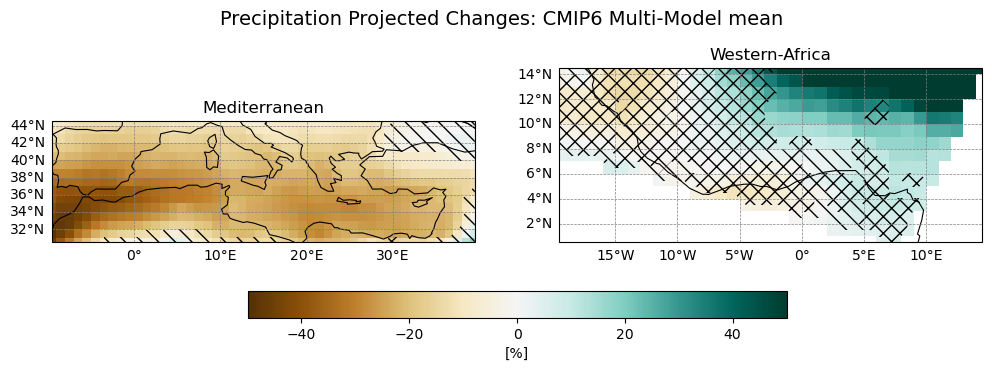

In [109]:
# Regional Axis
axis_med = proj_prct_mean.where(mask == reg_id_1).dropna(dim="lat", how="all").dropna(dim="lon", how="all")
axis_waf = proj_prct_mean.where(mask == reg_id_2).dropna(dim="lat", how="all").dropna(dim="lon", how="all")

# Define the Figure
fig, ax = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": ccrs.PlateCarree()})
for i in range(2):

    im = ax[i].pcolormesh(proj.lon, proj.lat, proj_prct_region.isel(region=i).mean(dim='member', skipna=True),
        transform=ccrs.PlateCarree(),
        vmin = -50,
        vmax = 50,
        cmap="BrBG",
    )
    ax[i].coastlines(resolution="110m", linewidth=0.8)

    ax[i].contourf(proj.lon, proj.lat, agree2.isel(region=i), levels=[-0.5, 0.5], colors='none', hatches=['\\\\'])
    ax[i].contourf(proj.lon, proj.lat, agree3.isel(region=i), levels=[0.5, 1.5], colors='none', hatches=['xx'])

    if i==0:
        ax[i].set_extent([min(axis_med.lon), max(axis_med.lon), min(axis_med.lat), max(axis_med.lat)], crs=ccrs.PlateCarree())
    else:
        ax[i].set_extent([min(axis_waf.lon), max(axis_waf.lon), min(axis_waf.lat), max(axis_waf.lat)], crs=ccrs.PlateCarree())
    
    gl = ax[i].gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    ax[i].set_ylabel("Lat")
    ax[i].set_xlabel("Lon")
    ax[i].set_title(f"{proj_prct_region.isel(region=i).region.values}")


cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        fraction=0.05,
        pad=0.09,
)
cbar.set_label("[%]")

fig.suptitle("Precipitation Projected Changes: CMIP6 Multi-Model mean", y=0.55, fontsize=14)
plt.show()